# Title: Sales Prediction Using Advertising Data

<h1 style="font-family: 'poppins'; font-weight: bold; color: Green;">👨‍💻Author: Dr. Muneeb Hassan</h1>

[![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/MUNEEB-HASSAN)  
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-blue?style=for-the-badge&logo=kaggle)](https://www.kaggle.com/MUNEEBHASSAN)  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/muneebhassansipra)


## impporting Libarires and load datast

In [19]:
# 📦 Basic Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# 📍 Display Settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# 📂 Unzipping the dataset
zip_path = r"C:\Users\hassa\Downloads\archive (2).zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("extracted_dataset")  # Unzipped to this folder

# 📁 Check extracted files
extracted_path = "extracted_dataset"
print("Extracted files:", os.listdir(extracted_path))

# 📄 Load CSV file (you may need to update the file name after checking the output of os.listdir)
file_name = os.listdir(extracted_path)[0]  # auto-pick first file (or set manually)
df = pd.read_csv(os.path.join(extracted_path, file_name))

# 🔍 Quick look at the dataset
print("Shape:", df.shape)
df.head()


Extracted files: ['Advertising.csv']
Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [20]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [21]:
# Check for nulls
print("Missing values:\n", df.isnull().sum())

Missing values:
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [22]:
# Drop the index column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [23]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [24]:
# 1. Unique values in each column
print("🔢 Unique values:\n", df.nunique())


🔢 Unique values:
 TV           190
Radio        167
Newspaper    172
Sales        121
dtype: int64


In [25]:

# 2. Variance of each feature
print("\n📊 Variance of features:\n", df.var())



📊 Variance of features:
 TV           7370.949893
Radio         220.427743
Newspaper     474.308326
Sales          27.221853
dtype: float64


In [26]:
# 3. Skewness of the features
print("\n📈 Skewness:\n", df.skew())


📈 Skewness:
 TV          -0.069853
Radio        0.094175
Newspaper    0.894720
Sales        0.407571
dtype: float64


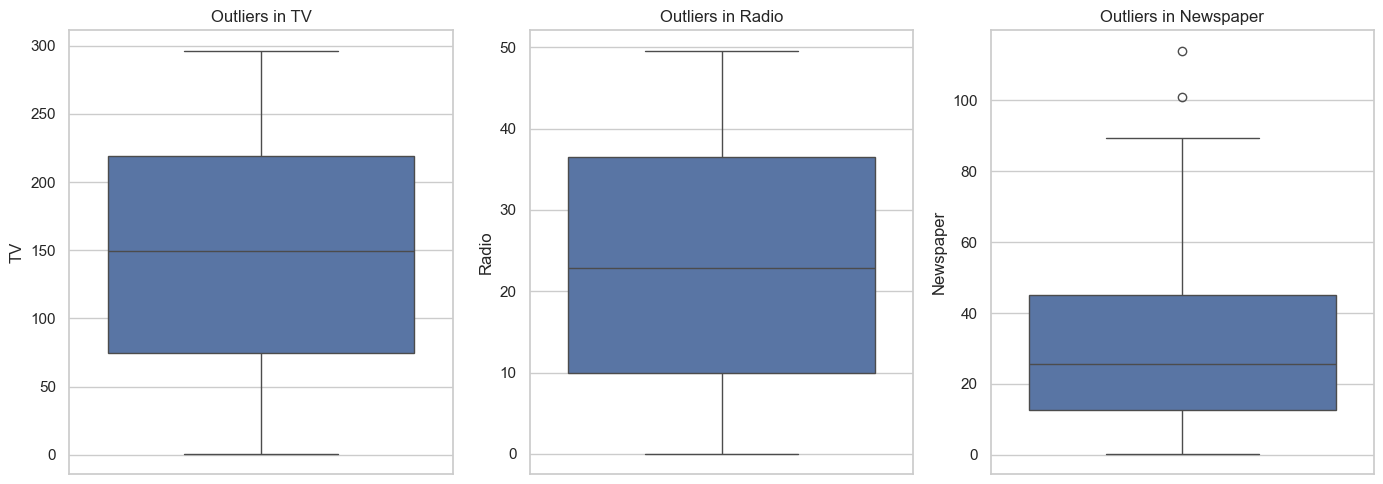

In [27]:
 # Boxplots to detect outliers
plt.figure(figsize=(14, 5))
for i, column in enumerate(df.columns[:-1], 1):  # exclude Sales
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f"Outliers in {column}")
plt.tight_layout()
plt.show()

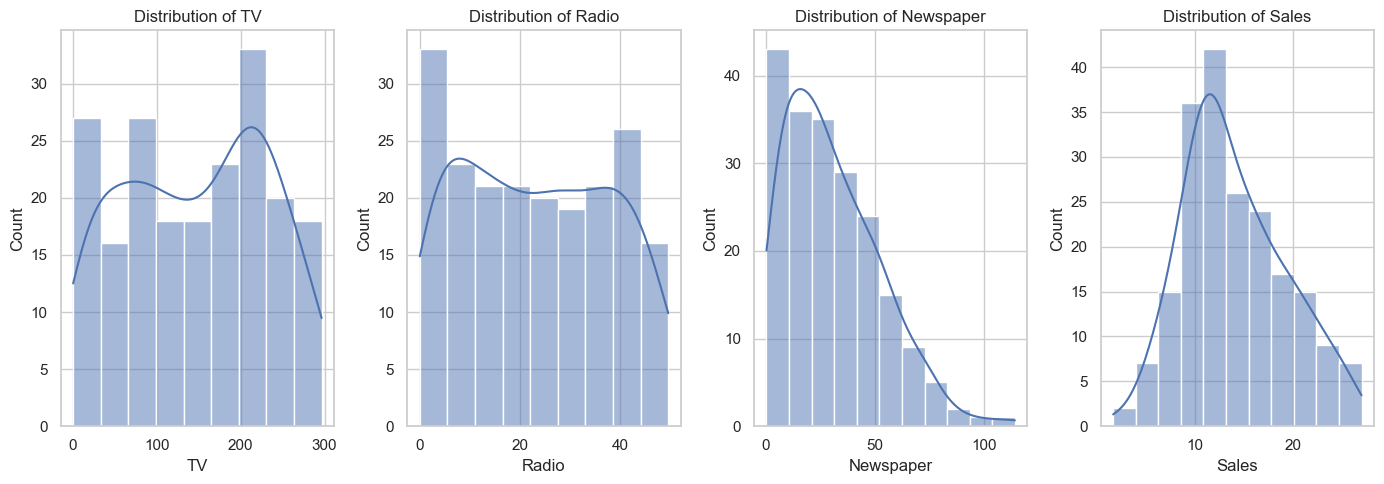

In [28]:
# 5. Distribution plots
plt.figure(figsize=(14, 5))
for i, column in enumerate(df.columns, 1):
    plt.subplot(1, 4, i)
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()


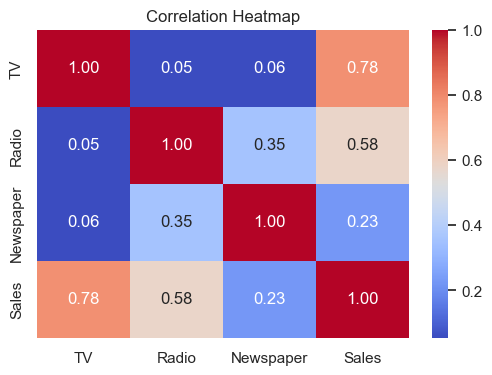

In [29]:


# 6. Correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['TV', 'Radio', 'Newspaper']])


# model Linear regression

In [31]:
# 📦 Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 🎯 Features and Target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 🔀 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🚀 Train Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 📈 Predict
y_pred = lr_model.predict(X_test)

# 📊 Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ R² Score: {r2:.4f}")
print(f"📉 RMSE: {rmse:.4f}")


✅ R² Score: 0.8994
📉 RMSE: 1.7816


In [32]:
# 🔍 Coefficients (Impact of each ad channel)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
print(coefficients)


     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


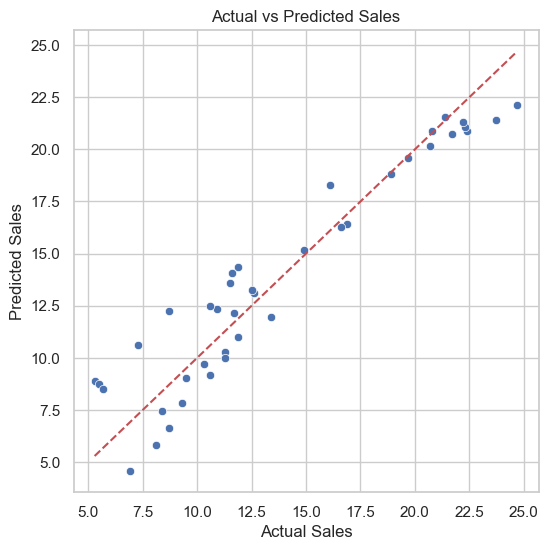

In [33]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.grid(True)
plt.show()


C:\Users\hassa\AppData\Local\Temp\ipykernel_11744\1796127734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')


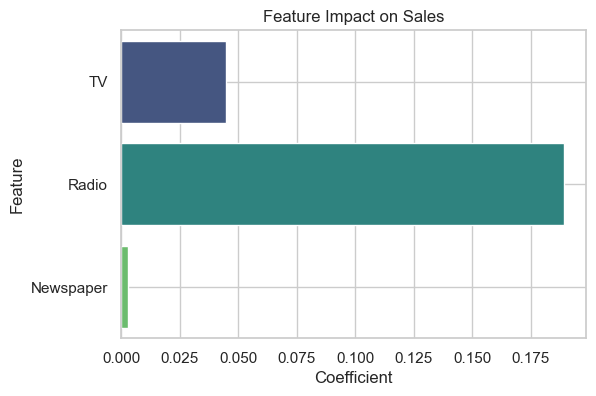

In [34]:
# Plot feature importances
plt.figure(figsize=(6, 4))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')
plt.title("Feature Impact on Sales")
plt.grid(True)
plt.show()
